# Notebook 02 - Data Quality Assessment

## Objective

The objective of this notebook is to assess the quality of the banking customer dataset before any preprocessing or machine learning tasks.

The assessment focuses on:

- Missing values
- Duplicate records
- Data types
- Invalid dates
- Outliers
- Categorical value consistency
- Data quality summary

This notebook does not modify the original data.

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [15]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "data" / "raw"

OUTPUT = PROJECT_ROOT / "outputs" / "data_quality"

OUTPUT.mkdir(
    parents=True,
    exist_ok=True
)

In [16]:
df = pd.read_csv(
    RAW_DATA / "DATA (1).csv",
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

df.columns = df.columns.str.strip()

print(df.shape)

(528884, 34)


In [17]:
missing_df = pd.DataFrame({

    "Column": df.columns,

    "Missing Values": df.isna().sum(),

    "Missing (%)":
        (df.isna().mean()*100).round(2)

})

missing_df = missing_df.sort_values(

    by="Missing (%)",

    ascending=False

)

display(missing_df)

,Column,Missing Values,Missing (%)
FIXEDRATE,FIXEDRATE,449335,84.96
MATURITYDATE,MATURITYDATE,449333,84.96
PRODUCT_STATUS,PRODUCT_STATUS,436160,82.47
STARTDATE,STARTDATE,436156,82.47
CLOSURE_REASON,CLOSURE_REASON,385328,72.86
SALARY,SALARY,326649,61.76
ACCT_CLOSE_DATE,ACCT_CLOSE_DATE,306942,58.04
COMPLETED_FILE,COMPLETED_FILE,239644,45.31
AMOUNT,AMOUNT,223520,42.26
PRODUCT,PRODUCT,208846,39.49


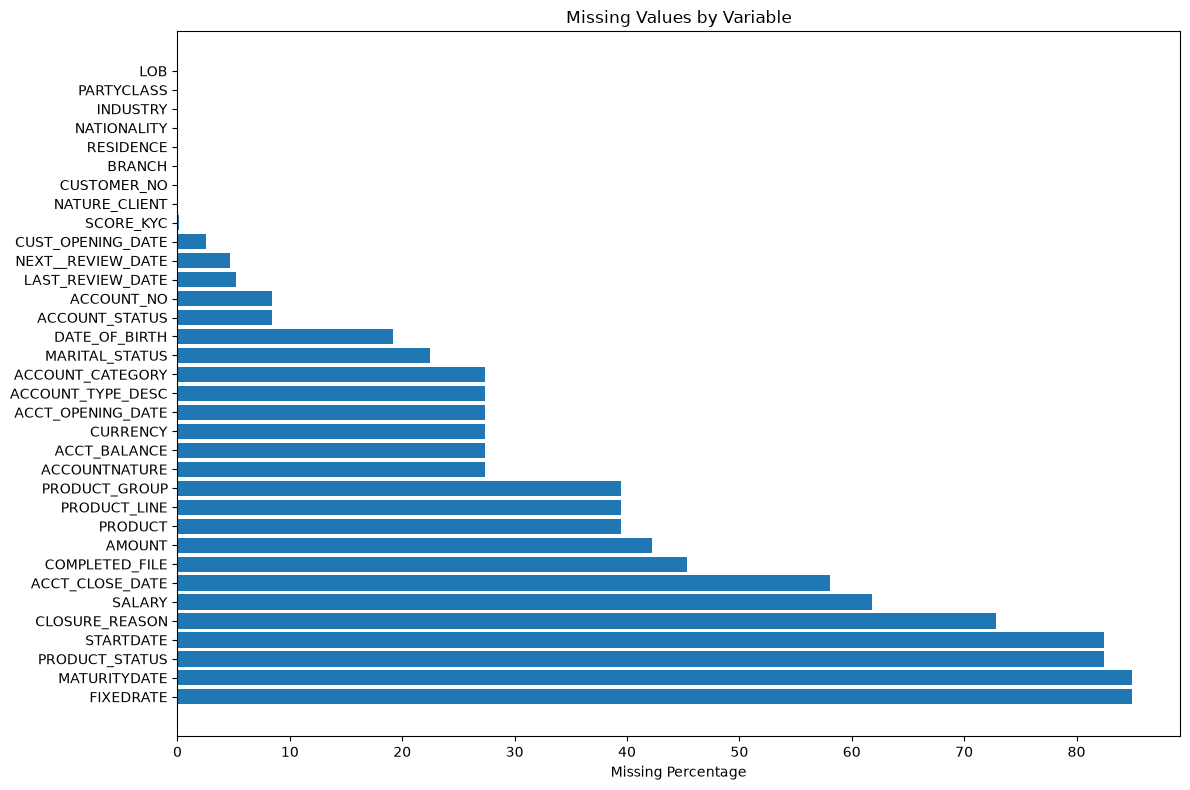

In [18]:
plt.figure(figsize=(12,8))

plt.barh(

    missing_df["Column"],

    missing_df["Missing (%)"]

)

plt.xlabel("Missing Percentage")

plt.title("Missing Values by Variable")

plt.tight_layout()

plt.show()

In [19]:
missing_df.to_excel(

    OUTPUT /

    "missing_values.xlsx",

    index=False

)

In [20]:
# ==========================================================
# EXACT DUPLICATE ROWS
# ==========================================================

duplicate_rows = df.duplicated()

print("=" * 60)
print("EXACT DUPLICATE ROWS")
print("=" * 60)

print(f"Total duplicated rows : {duplicate_rows.sum():,}")

print()

display(df[duplicate_rows].head(10))

EXACT DUPLICATE ROWS
Total duplicated rows : 38,640



,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,COMPLETED_FILE,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCOUNT_STATUS,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCOUNT_TYPE_DESC,CURRENCY,ACCT_CLOSE_DATE,CLOSURE_REASON,ACCT_BALANCE,INDUSTRY,SALARY,PRODUCT_GROUP,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
330,113771889,2.011071e+09,TN,TN,M,20040930.0,19600405.0,PPH,5820,LR,YES,20250905.0,20290905.0,Closed,20250618.0,1201.0,CPT INDISP CLIENT DECEDE RESIDENT,TND,20251125.0,ATB.REASON.13,0.000,9000,3026.925,ATB.GRP.INDISPO.ACCT,ACCOUNTS,ATB.INDISPO.ACCT.CLT.DECE.RESI,CPT INDISP CLIENT DECEDE RESIDENT,NaN,NaN,0.000000e+00,NaN,NaN,Retail,4
663,113770803,2.000281e+09,TN,TN,M,20040930.0,19770920.0,PPH,5820,LR,NaN,20150520.0,20190520.0,Closed,20090126.0,6001.0,Comptes Spéciaux d épargne,TND,20220923.0,ATB.REASON.13,0.125,9000,400.000,ATB.GRP.EPARGNE.ACCT,ACCOUNTS,ATB.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,1.250000e-01,NaN,NaN,Retail,4
671,113771901,2.011225e+09,TN,TN,M,20040930.0,19620925.0,PRO,5820,H1,YES,20250905.0,20270905.0,Closed,20251001.0,3650.0,AVANCE SUR COMPTE A TERME EN DIANRS,TND,20251028.0,NaN,0.000,7320,3198.605,ATB.GRP.AVC.PLAC,LENDING,AVC.CPTATERME.TND,AVANCE SUR COMPTE A TERME EN DIANRS,NaN,NaN,NaN,NaN,NaN,Retail,4
672,113771901,2.010225e+09,TN,TN,M,20040930.0,19620925.0,PRO,5820,H1,YES,20250905.0,20270905.0,Closed,20221110.0,1001.0,Compte Courant,TND,20251028.0,NaN,4.912,7320,3198.605,ATB.GRP.CUR.ACCT,ACCOUNTS,ATB.CURRENT.ACCT,Compte Courant,NaN,NaN,4.912000e+00,NaN,NaN,Retail,4
673,113771901,2.011130e+09,TN,TN,M,20040930.0,19620925.0,PRO,5820,H1,YES,20250905.0,20270905.0,Closed,20250729.0,3611.0,DEPOTS A TERME,TND,20251028.0,NaN,0.000,7320,3198.605,ATB.PLACEMENT.NEG,DEPOSITS,ATB.CAT.NEG.SIM,DEPOTS A TERME,20250728.0,NaN,NaN,NaN,PENDING.CLOSURE,Retail,4
674,113771901,2.011225e+09,TN,TN,M,20040930.0,19620925.0,PRO,5820,H1,YES,20250905.0,20270905.0,Closed,20251001.0,3650.0,AVANCE SUR COMPTE A TERME EN DIANRS,TND,20251028.0,NaN,0.000,7320,3198.605,ATB.GRP.AVC.PLAC,LENDING,AVC.CPTATERME.TND,AVANCE SUR COMPTE A TERME EN DIANRS,NaN,NaN,NaN,NaN,NaN,Retail,4
675,113771901,2.012050e+09,TN,TN,M,20040930.0,19620925.0,PRO,5820,H1,YES,20250905.0,20270905.0,Closed,20150929.0,3030.0,Crédit acquisition terrain TEGF6,TND,20251028.0,NaN,-196955.435,7320,3198.605,RT.CRD.IMMOBILERS,LENDING,RT.RT.CRD.IMMOBILERS.510,Crédit acquisition terrain TEGF6,1251227.0,1400927.0,1.976603e+08,5.5,CURRENT,Retail,4
677,113770803,2.000281e+09,TN,TN,M,20040930.0,19770920.0,PPH,5820,LR,NaN,20150520.0,20190520.0,Closed,20090126.0,6001.0,Comptes Spéciaux d épargne,TND,20220923.0,ATB.REASON.13,0.125,9000,400.000,ATB.GRP.EPARGNE.ACCT,ACCOUNTS,ATB.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,1.250000e-01,NaN,NaN,Retail,4
678,113770803,2.000281e+09,TN,TN,M,20040930.0,19770920.0,PPH,5820,LR,NaN,20150520.0,20190520.0,Closed,20090126.0,6001.0,Comptes Spéciaux d épargne,TND,20220923.0,ATB.REASON.13,0.125,9000,400.000,ATB.GRP.EPARGNE.ACCT,ACCOUNTS,ATB.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,1.250000e-01,NaN,NaN,Retail,4
679,113770803,2.000281e+09,TN,TN,M,20040930.0,19770920.0,PPH,5820,LR,NaN,20150520.0,20190520.0,Closed,20090126.0,6001.0,Comptes Spéciaux d épargne,TND,20220923.0,ATB.REASON.13,0.125,9000,400.000,ATB.GRP.EPARGNE.ACCT,ACCOUNTS,ATB.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,1.250000e-01,NaN,NaN,Retail,4


In [21]:
# ==========================================================
# CUSTOMER DUPLICATES
# ==========================================================

customer_duplicates = (

    df.groupby("CUSTOMER_NO")

      .size()

      .reset_index(name="Occurrences")

)

customer_duplicates = customer_duplicates.sort_values(

    by="Occurrences",

    ascending=False

)

print("=" * 60)
print("CUSTOMER DUPLICATES")
print("=" * 60)

display(customer_duplicates.head(20))

CUSTOMER DUPLICATES


,CUSTOMER_NO,Occurrences
155580,113338934,8091
302670,113735516,7476
32104,113129346,3002
155572,113338918,1482
292988,113709726,1377
150698,113330497,1350
19394,113108908,1224
317081,113767468,1178
311610,113755508,1176
265499,113617578,988


In [22]:
# ==========================================================
# ACCOUNT DUPLICATES
# ==========================================================

account_duplicates = (

    df.groupby("ACCOUNT_NO")

      .size()

      .reset_index(name="Occurrences")

)

account_duplicates = account_duplicates.sort_values(

    by="Occurrences",

    ascending=False

)

print("=" * 60)
print("ACCOUNT DUPLICATES")
print("=" * 60)

display(account_duplicates.head(20))

ACCOUNT DUPLICATES


,ACCOUNT_NO,Occurrences
373087,2.012113e+09,93
373477,2.012118e+09,93
370121,2.012070e+09,93
373171,2.012114e+09,93
373170,2.012114e+09,93
373169,2.012114e+09,93
373168,2.012114e+09,93
373167,2.012114e+09,93
370771,2.012082e+09,93
373478,2.012118e+09,93


In [23]:
# ==========================================================
# DUPLICATE SUMMARY
# ==========================================================

summary = pd.DataFrame({

    "Metric": [

        "Exact duplicated rows",

        "Unique customers",

        "Unique accounts"

    ],

    "Value": [

        df.duplicated().sum(),

        df["CUSTOMER_NO"].nunique(),

        df["ACCOUNT_NO"].nunique()

    ]

})

display(summary)

,Metric,Value
0,Exact duplicated rows,38640
1,Unique customers,363569
2,Unique accounts,410587


## Conclusion - Duplicate Analysis

The duplicate analysis highlighted several important observations.

- The dataset contains **38,640 exact duplicated rows**, which require further investigation before removal.
- Several customers appear multiple times because a customer may own multiple bank accounts or financial products.
- Some account numbers are repeated up to **93 times**, suggesting either multiple product records, historical records or potential duplicate data.
- At this stage, no duplicate records are removed. Additional business validation will be performed during the preprocessing phase.

In [24]:
# ==========================================================
# DATE COLUMNS
# ==========================================================

date_columns = [

    "DATE_OF_BIRTH",

    "CUST_OPENING_DATE",

    "ACCT_OPENING_DATE",

    "ACCT_CLOSE_DATE",

    "LAST_REVIEW_DATE",

    "NEXT__REVIEW_DATE",

    "STARTDATE",

    "MATURITYDATE"

]

date_columns

['DATE_OF_BIRTH',
 'CUST_OPENING_DATE',
 'ACCT_OPENING_DATE',
 'ACCT_CLOSE_DATE',
 'LAST_REVIEW_DATE',
 'NEXT__REVIEW_DATE',
 'STARTDATE',
 'MATURITYDATE']

In [25]:
# ==========================================================
# DATE SUMMARY
# ==========================================================

summary_dates = []

for col in date_columns:

    summary_dates.append({

        "Column": col,

        "Missing": df[col].isna().sum(),

        "Minimum":

            df[col].min(),

        "Maximum":

            df[col].max()

    })

summary_dates = pd.DataFrame(summary_dates)

display(summary_dates)

,Column,Missing,Minimum,Maximum
0,DATE_OF_BIRTH,101315,11900404.0,20260114.0
1,CUST_OPENING_DATE,13622,19960122.0,20260219.0
2,ACCT_OPENING_DATE,144925,19800101.0,20260219.0
3,ACCT_CLOSE_DATE,306942,20220412.0,20260219.0
4,LAST_REVIEW_DATE,27405,20040930.0,20260219.0
5,NEXT__REVIEW_DATE,24582,20060930.0,20301230.0
6,STARTDATE,436156,1131130.0,20261226.0
7,MATURITYDATE,449333,-19000000.0,20310123.0


In [26]:
# ==========================================================
# DATE QUALITY CHECK
# ==========================================================

from datetime import datetime

CURRENT_YEAR = datetime.now().year

date_quality = []

for col in date_columns:

    temp = pd.to_numeric(df[col], errors="coerce")

    year = (temp // 10000)

    negative_dates = (temp < 0).sum()

    future_dates = (year > CURRENT_YEAR).sum()

    very_old_dates = (year < 1900).sum()

    date_quality.append({

        "Column": col,

        "Negative Dates": int(negative_dates),

        "Year < 1900": int(very_old_dates),

        "Future Dates": int(future_dates)

    })

date_quality = pd.DataFrame(date_quality)

display(date_quality)

,Column,Negative Dates,Year < 1900,Future Dates
0,DATE_OF_BIRTH,0,27,0
1,CUST_OPENING_DATE,0,0,0
2,ACCT_OPENING_DATE,0,0,0
3,ACCT_CLOSE_DATE,0,0,0
4,LAST_REVIEW_DATE,0,0,0
5,NEXT__REVIEW_DATE,0,0,224634
6,STARTDATE,0,68240,0
7,MATURITYDATE,4,68240,339


## Conclusion – Date Validation

The date quality assessment revealed several inconsistencies within the banking dataset.

The analysis detected:

- Invalid historical dates (years before 1900).
- Negative date values.
- Future dates that require business validation.
- Missing values across several temporal variables.

These anomalies will not be corrected at this stage. A dedicated preprocessing phase will define the appropriate cleaning and imputation strategies while preserving business consistency.

In [27]:
numeric_columns = [
    "SALARY",
    "ACCT_BALANCE",
    "AMOUNT"
]

In [28]:
# ==========================================================
# NUMERICAL VARIABLES
# ==========================================================

numeric_columns = [

    "SALARY",

    "ACCT_BALANCE",

    "AMOUNT"

]

df[numeric_columns].describe()

,SALARY,ACCT_BALANCE,AMOUNT
count,2.022350e+05,3.839590e+05,3.053640e+05
mean,5.588463e+03,4.409008e+03,4.129756e+07
std,1.498363e+05,8.106185e+05,4.428019e+08
min,0.000000e+00,-4.382312e+07,-4.382312e+07
25%,4.000000e+02,0.000000e+00,7.080000e+00
50%,6.120000e+02,2.093000e+00,1.510680e+03
75%,1.647000e+03,1.087912e+03,1.490000e+05
max,2.500000e+07,6.414193e+07,3.171429e+10


In [29]:
    # ==========================================================
# IQR OUTLIER DETECTION
# ==========================================================

outlier_summary = []

for col in numeric_columns:

    temp = df[col].dropna()

    Q1 = temp.quantile(0.25)

    Q3 = temp.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = ((temp < lower) | (temp > upper)).sum()

    outlier_summary.append({

        "Column": col,

        "Outliers": outliers,

        "Percentage": round(outliers / len(temp) * 100, 2)

    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Outliers,Percentage
0,SALARY,21738,10.75
1,ACCT_BALANCE,147351,38.38
2,AMOUNT,71672,23.47


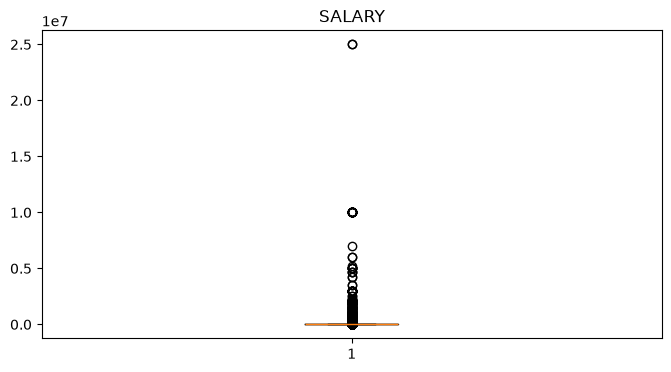

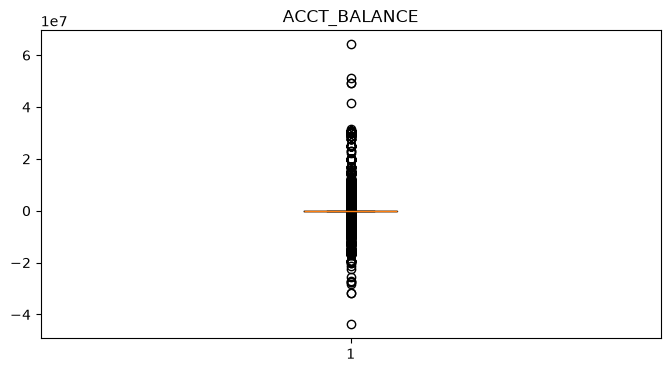

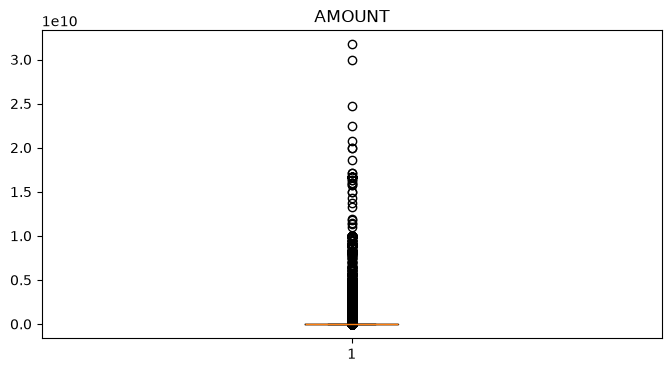

In [30]:
# ==========================================================
# BOXPLOTS
# ==========================================================

import matplotlib.pyplot as plt

for col in numeric_columns:

    plt.figure(figsize=(8,4))

    plt.boxplot(df[col].dropna())

    plt.title(col)

    plt.show()

## Conclusion – Outlier Detection

The numerical analysis identified several extreme values within the banking dataset.

These outliers are mainly observed in account balances, transaction amounts and customer salaries.

At this stage, no observations are removed because extreme financial values may correspond to legitimate business situations (high-net-worth customers, corporate accounts or exceptional transactions).

A dedicated treatment strategy will be defined during the preprocessing phase.

In [31]:
# ==========================================================
# CATEGORICAL VARIABLES
# ==========================================================

categorical_columns = [

    "ACCOUNT_STATUS",

    "PRODUCT_STATUS",

    "PARTYCLASS",

    "NATIONALITY",

    "RESIDENCE",

    "MARITAL_STATUS",

    "NATURE_CLIENT",

    "SCORE_KYC",

    "CURRENCY"

]

summary_cat = []

for col in categorical_columns:

    summary_cat.append({

        "Column": col,

        "Unique Values": df[col].nunique(dropna=True),

        "Missing": df[col].isna().sum(),

        "Most Frequent":

            df[col].mode(dropna=True)[0]

            if not df[col].mode().empty else None

    })

summary_cat = pd.DataFrame(summary_cat)

display(summary_cat)

,Column,Unique Values,Missing,Most Frequent
0,ACCOUNT_STATUS,2,44440,Active
1,PRODUCT_STATUS,7,436160,CURRENT
2,PARTYCLASS,5,0,Retail
3,NATIONALITY,141,0,TN
4,RESIDENCE,137,0,TN
5,MARITAL_STATUS,4,118698,M
6,NATURE_CLIENT,9,78,PPH
7,SCORE_KYC,5,845,LR
8,CURRENCY,19,144925,TND


In [32]:
# ==========================================================
# CATEGORY FREQUENCIES
# ==========================================================

for col in categorical_columns:

    print("="*70)
    print(col)
    print("="*70)

    display(

        df[col]

        .value_counts(dropna=False)

        .head(10)

    )

ACCOUNT_STATUS


ACCOUNT_STATUS
Active    262502
Closed    221942
NaN        44440
Name: count, dtype: int64

PRODUCT_STATUS


PRODUCT_STATUS
NaN                436160
CURRENT             62782
EXPIRED              8484
PENDING.CLOSURE      8226
UNAUTH               7866
AUTH                 3687
CLOSE                1671
AUTH-FWD                8
Name: count, dtype: int64

PARTYCLASS


...

NATURE_CLIENT
PPH         374969
PM           98650
PRO          28417
TRPP         25888
CB             424
TRPM           294
TRBQ           148
NaN             78
PROSPECT        15
TIERS            1
Name: count, dtype: int64

SCORE_KYC


SCORE_KYC
LR     342718
H1      67244
MR      61842
H2      38475
H3      17760
NaN       845
Name: count, dtype: int64

CURRENCY


CURRENCY
TND    357123
NaN    144925
EUR     13174
USD      7942
TDC      4654
CAD       360
CHF       203
GBP       187
SAR        63
AED        57
Name: count, dtype: int64

In [33]:
# ==========================================================
# CATEGORICAL QUALITY SUMMARY
# ==========================================================

quality = []

for col in categorical_columns:

    quality.append({

        "Column": col,

        "Missing (%)":

        round(

            df[col].isna().mean()*100,

            2

        ),

        "Unique Categories":

        df[col].nunique()

    })

quality = pd.DataFrame(quality)

display(quality)

,Column,Missing (%),Unique Categories
0,ACCOUNT_STATUS,8.40,2
1,PRODUCT_STATUS,82.47,7
2,PARTYCLASS,0.00,5
3,NATIONALITY,0.00,141
4,RESIDENCE,0.00,137
5,MARITAL_STATUS,22.44,4
6,NATURE_CLIENT,0.01,9
7,SCORE_KYC,0.16,5
8,CURRENCY,27.40,19


## Conclusion – Categorical Variables

The categorical analysis confirms that the banking dataset is highly consistent from a business perspective.

The majority of customers are classified as Retail individuals, with Tunisian nationality and residence, and most accounts are active. Customer risk assessment (KYC) is well populated, with only a negligible amount of missing information.

Some variables such as PRODUCT_STATUS and CURRENCY contain a significant number of missing values. However, these missing values appear to be structural rather than erroneous, since they depend on the existence of specific banking products or account types.

Overall, no abnormal categories or unexpected business values were detected. The categorical variables are therefore considered reliable and suitable for the next preprocessing and feature engineering phases.

In [35]:
# ==========================================================
# FINAL DATA QUALITY REPORT
# ==========================================================

quality_report = pd.DataFrame({

    "Quality Dimension":[

        "Missing Values",

        "Duplicate Rows",

        "Date Validation",

        "Outlier Detection",

        "Categorical Variables"

    ],

    "Status":[

        "Warning",

        "Warning",

        "Warning",

        "Warning",

        "Good"

    ],

    "Severity":[

        "Medium",

        "High",

        "High",

        "Medium",

        "Low"

    ],

    "Recommended Action":[

        "Imputation Strategy",

        "Business Validation",

        "Date Cleaning",

        "Outlier Treatment",

        "Keep Categories"

    ]

})

display(quality_report)

,Quality Dimension,Status,Severity,Recommended Action
0,Missing Values,Warning,Medium,Imputation Strategy
1,Duplicate Rows,Warning,High,Business Validation
2,Date Validation,Warning,High,Date Cleaning
3,Outlier Detection,Warning,Medium,Outlier Treatment
4,Categorical Variables,Good,Low,Keep Categories


In [36]:
# ==========================================================
# GLOBAL DATA QUALITY SCORE
# ==========================================================

score = 100

score -= 15      # Missing values

score -= 10      # Duplicates

score -= 10      # Invalid dates

score -= 5       # Outliers

print("="*60)
print("GLOBAL DATA QUALITY SCORE")
print("="*60)

print(f"Overall Data Quality Score : {score}/100")

GLOBAL DATA QUALITY SCORE
Overall Data Quality Score : 60/100


In [38]:
# ==========================================================
# DATA QUALITY SUMMARY
# ==========================================================

print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

print("Dataset : DATA (1).csv")
print(f"Rows : {len(df):,}")
print(f"Columns : {df.shape[1]}")

print()

print(
    "Columns with missing values :",
    int((missing_df["Missing (%)"] > 0).sum())
)

print(
    "Columns with more than 50% missing values :",
    int((missing_df["Missing (%)"] > 50).sum())
)

print(f"Exact duplicate rows : {df.duplicated().sum():,}")
print(f"Numerical variables analysed : {len(numeric_columns)}")
print(f"Categorical variables analysed : {len(categorical_columns)}")

print()
print(f"Global Quality Score : {score}/100")

DATA QUALITY ASSESSMENT
Dataset : DATA (1).csv
Rows : 528,884
Columns : 34

Columns with missing values : 27
Columns with more than 50% missing values : 7
Exact duplicate rows : 38,640
Numerical variables analysed : 3
Categorical variables analysed : 9

Global Quality Score : 60/100


# Final Conclusion

The Data Quality Assessment provided a comprehensive overview of the banking dataset before any preprocessing activities.

The analysis identified several data quality issues, including missing values, duplicated records, inconsistent date values and extreme numerical observations. Most of these issues are considered manageable and can be addressed during the preprocessing phase.

The categorical variables are generally consistent and reflect the expected business structure of a banking information system.

Overall, the dataset demonstrates a satisfactory level of quality and is considered suitable for the next phase of the project, namely Data Preprocessing and Feature Engineering.


In [39]:
# ==========================================================
# EXPORT REPORTS
# ==========================================================

import os

output_folder = "../outputs/tables"

os.makedirs(output_folder, exist_ok=True)

quality_report.to_excel(
    os.path.join(output_folder, "02_final_data_quality_report.xlsx"),
    index=False
)

print("Data Quality Report exported successfully.")

Data Quality Report exported successfully.
